In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
test_results = pd.read_csv('test_results/finetune_mskcc_blur0.csv')
test_results['isic_id'] = test_results['file'].apply(lambda x: x.split('/')[-1].split('.')[0])

test_results['fp'] += 1 # 1-6 Fitzpatrick scale
test_results['pred'] += 1

mskcc_df = pd.read_csv('data/mskcc/metadata.csv')
# merge with test_results
test_results = test_results.merge(mskcc_df, on='isic_id', how='left')

# keep only image_type = dermoscopic
test_results = test_results[test_results['image_type'] == 'dermoscopic']

test_results.head()

,fp,pred,file,fold,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,...,dermoscopic_type,diagnosis_1,diagnosis_2,diagnosis_confirm_type,fitzpatrick_skin_type,image_type,lesion_id,melanocytic,patient_id,sex
0,4,4,data/mskcc/images/ISIC_0077599.jpg,0,ISIC_0077599,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,anterior torso,NaN,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,IV,dermoscopic,IL_4740307,False,IP_5007819,male
1,2,2,data/mskcc/images/ISIC_0086394.jpg,0,ISIC_0086394,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,upper extremity,NaN,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_3561573,False,IP_7410598,female
2,5,5,data/mskcc/images/ISIC_0087198.jpg,0,ISIC_0087198,Memorial Sloan Kettering Cancer Center,CC-BY,45.0,lower extremity,acral palms or soles,...,non-contact polarized,Benign,Benign - Other,single contributor clinical assessment,V,dermoscopic,IL_6643442,False,IP_4485945,male
3,4,3,data/mskcc/images/ISIC_0107306.jpg,0,ISIC_0107306,Memorial Sloan Kettering Cancer Center,CC-BY,55.0,upper extremity,NaN,...,contact non-polarized,Benign,NaN,single contributor clinical assessment,IV,dermoscopic,IL_5749665,NaN,IP_9772523,male
4,2,3,data/mskcc/images/ISIC_0107551.jpg,0,ISIC_0107551,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,anterior torso,NaN,...,contact polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_6914231,False,IP_7410598,female


In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from scipy.stats import bootstrap

def patient_bootstrap_mean_ci(
    df: pd.DataFrame,
    value_col: str,
    patient_col: str = "patient_id",
    *,
    n_resamples: int = 5000,
    confidence_level: float = 0.95,
    method: str = "percentile",   # or "BCa"
    random_state: int = 0,
):
    """
    Patient-level (cluster) bootstrap CI for the MEAN of a per-row metric
    (e.g., Delta E computed per image/lesion/site).

    Resamples patients with replacement; includes all rows for each sampled patient.
    """
    d = df[[patient_col, value_col]].dropna().copy()
    vals_by_patient = []
    patient_ids = []

    for pid, sub in d.groupby(patient_col, sort=False):
        patient_ids.append(pid)
        vals_by_patient.append(sub[value_col].to_numpy(dtype=float, copy=False))

    patient_ids = np.array(patient_ids)
    if patient_ids.size < 2:
        raise ValueError("Need at least 2 patients for a patient-level bootstrap.")

    # Point estimate: mean over all rows once
    point_est = float(d[value_col].to_numpy(dtype=float, copy=False).mean())

    # Fast lookup dict
    grouped = {pid: v for pid, v in zip(patient_ids, vals_by_patient)}

    def stat(resampled_patient_ids, axis=-1):
        ids = np.asarray(resampled_patient_ids)
        parts = [grouped[pid] for pid in ids]  # patients can repeat
        x = np.concatenate(parts, axis=0)
        return float(np.mean(x))

    res = bootstrap(
        data=(patient_ids,),
        statistic=stat,
        vectorized=False,
        paired=False,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method=method,
        random_state=np.random.default_rng(random_state),
    )

    return {
        "mean": point_est,
        "ci_low": float(res.confidence_interval.low),
        "ci_high": float(res.confidence_interval.high),
        "n_patients": int(patient_ids.size),
        "n_rows": int(len(d)),
        "method": method,
        "n_resamples": int(n_resamples),
        "confidence_level": float(confidence_level),
    }

def patient_bootstrap_kappa_ci(
    df: pd.DataFrame,
    patient_col: str = "patient_id",
    y_true_col: str = "fp",
    y_pred_col: str = "pred",
    *,
    weights: str = "linear",
    labels = (1, 2, 3, 4, 5, 6),
    n_resamples: int = 5000,
    confidence_level: float = 0.95,
    method: str = "percentile",   # "BCa" is also available in SciPy
    random_state: int = 0,
):
    """
    Patient-level (cluster) bootstrap CI for Cohen's kappa.

    Assumes df contains ONE prediction per row (e.g., out-of-fold prediction).
    Resamples patients with replacement; includes all rows for each sampled patient.
    """
    # Ensure clean types
    d = df[[patient_col, y_true_col, y_pred_col]].dropna().copy()
    d[y_true_col] = d[y_true_col].astype(int)
    d[y_pred_col] = d[y_pred_col].astype(int)

    # Pre-split data by patient for fast lookup
    grouped = {}
    for pid, sub in d.groupby(patient_col, sort=False):
        grouped[pid] = (
            sub[y_true_col].to_numpy(dtype=int, copy=False),
            sub[y_pred_col].to_numpy(dtype=int, copy=False),
        )

    patient_ids = np.array(list(grouped.keys()))
    if patient_ids.size < 2:
        raise ValueError("Need at least 2 patients for a patient-level bootstrap.")

    # Point estimate on full dataset (all rows once)
    y_true_all = d[y_true_col].to_numpy(dtype=int, copy=False)
    y_pred_all = d[y_pred_col].to_numpy(dtype=int, copy=False)
    point_est = cohen_kappa_score(y_true_all, y_pred_all, weights=weights, labels=list(labels))

    # Statistic evaluated on a resampled set of patients
    def stat(resampled_patient_ids, axis=-1):
        # scipy.stats.bootstrap passes an array; axis is unused here
        ids = np.asarray(resampled_patient_ids)

        # Concatenate rows for sampled patients (patients can repeat)
        y_true_parts = []
        y_pred_parts = []
        for pid in ids:
            yt, yp = grouped[pid]
            y_true_parts.append(yt)
            y_pred_parts.append(yp)

        y_true = np.concatenate(y_true_parts, axis=0)
        y_pred = np.concatenate(y_pred_parts, axis=0)

        return cohen_kappa_score(y_true, y_pred, weights=weights, labels=list(labels))

    res = bootstrap(
        data=(patient_ids,),
        statistic=stat,
        vectorized=False,
        paired=False,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method=method,
        random_state=np.random.default_rng(random_state),
    )

    return {
        "kappa": float(point_est),
        "ci_low": float(res.confidence_interval.low),
        "ci_high": float(res.confidence_interval.high),
        "n_patients": int(patient_ids.size),
        "n_rows": int(len(d)),
        "method": method,
        "n_resamples": int(n_resamples),
        "confidence_level": float(confidence_level),
    }

In [7]:
result = patient_bootstrap_kappa_ci(test_results, n_resamples=2000, method="BCa", random_state=42)
result

{'kappa': 0.5298034204618959,
 'ci_low': 0.4506526501524447,
 'ci_high': 0.6058031741314097,
 'n_patients': 64,
 'n_rows': 3678,
 'method': 'BCa',
 'n_resamples': 2000,
 'confidence_level': 0.95}

In [8]:
import numpy as np
import pandas as pd

def site_kappa_table_to_latex_percent(
    test_results: pd.DataFrame,
    *,
    site_col: str = "anatom_site_general",
    patient_col: str = "isic_id",
    y_true_col: str = "fp",
    y_pred_col: str = "pred",
    weights: str = "linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples: int = 2000,
    confidence_level: float = 0.95,
    method: str = "BCa",
    random_state: int = 42,
    min_patients: int = 2,
    caption: str = "Patient-level Cohen's $\\kappa$ by anatomical site (95\\% CI).",
    label: str = "tab:kappa_by_site",
):
    df = test_results.copy()

    sites = df[site_col].dropna().unique().tolist()
    sites.sort()

    rows = []

    for site in sites:
        site_df = df[df[site_col] == site].copy()
        n_pat = int(site_df[patient_col].nunique())
        n_rows = int(len(site_df))

        if n_pat < min_patients:
            rows.append({
                "Site": str(site),
                "Images (n)": n_rows,
                "kappa": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "Kappa [%] (95\\% CI)": "—",
            })
            continue

        res = patient_bootstrap_kappa_ci(
            site_df,
            patient_col=patient_col,
            y_true_col=y_true_col,
            y_pred_col=y_pred_col,
            weights=weights,
            labels=labels,
            n_resamples=n_resamples,
            confidence_level=confidence_level,
            method=method,
            random_state=random_state,
        )

        k, lo, hi = float(res["kappa"]), float(res["ci_low"]), float(res["ci_high"])
        rows.append({
            "Site": str(site),
            "Images (n)": n_rows,
            "kappa": k,
            "ci_low": lo,
            "ci_high": hi,
            "Kappa [%] (95\\% CI)": f"{k*100:.2f} ({lo*100:.2f}, {hi*100:.2f})",
        })

    site_df_out = pd.DataFrame(rows)

    df_all = df[[site_col, patient_col, y_true_col, y_pred_col]].dropna().copy()
    n_pat_all = int(df_all[patient_col].nunique())
    n_rows_all = int(len(df_all))

    overall = None
    if n_pat_all >= min_patients:
        overall = patient_bootstrap_kappa_ci(
            df_all,
            patient_col=patient_col,
            y_true_col=y_true_col,
            y_pred_col=y_pred_col,
            weights=weights,
            labels=labels,
            n_resamples=n_resamples,
            confidence_level=confidence_level,
            method=method,
            random_state=random_state,
        )

    def _esc(s: str) -> str:
        return (
            s.replace("&", r"\&")
             .replace("%", r"\%")
             .replace("_", r"\_")
             .replace("#", r"\#")
        )

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{5pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.15}")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{@{}l r l@{}}")
    lines.append(r"\toprule")
    lines.append(r"Site & Images ($n$) & $\kappa$ [\%] (95\% CI) \\")
    lines.append(r"\midrule")

    for _, r in site_df_out.iterrows():
        site = _esc(str(r["Site"]))
        im = int(r["Images (n)"])
        kcell = r["Kappa [%] (95\\% CI)"]
        lines.append(rf"{site} & {im} & {kcell} \\")

    lines.append(r"\midrule")
    if overall is None:
        lines.append(rf"\textbf{{Overall}} & {n_rows_all} & — \\")
    else:
        k = float(overall["kappa"])
        lo = float(overall["ci_low"])
        hi = float(overall["ci_high"])
        lines.append(rf"\textbf{{Overall}} & {n_rows_all} & {k*100:.2f} ({lo*100:.2f}, {hi*100:.2f}) \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    latex_str = "\n".join(lines)

    return site_df_out, latex_str


# --- Drop-in usage ---
site_kappa_df, site_kappa_latex = site_kappa_table_to_latex_percent(
    test_results,
    site_col="anatom_site_general",
    patient_col="isic_id",
    y_true_col="fp",
    y_pred_col="pred",
    weights="linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples=2000,
    confidence_level=0.95,
    method="BCa",
    random_state=42,
)

print(site_kappa_df)
print("\n" + site_kappa_latex)

              Site  Images (n)     kappa    ci_low   ci_high  \
0   anterior torso         683  0.515669  0.478447  0.550952   
1        head/neck         301  0.560367  0.516473  0.604394   
2    lateral torso          30  0.421488  0.215686  0.593593   
3  lower extremity         778  0.491779  0.459403  0.522827   
4      palms/soles          26  0.145714  0.055002  0.280566   
5  posterior torso         928  0.549568  0.520575  0.577480   
6  upper extremity         932  0.543024  0.511426  0.571568   

    Kappa [%] (95\% CI)  
0  51.57 (47.84, 55.10)  
1  56.04 (51.65, 60.44)  
2  42.15 (21.57, 59.36)  
3  49.18 (45.94, 52.28)  
4   14.57 (5.50, 28.06)  
5  54.96 (52.06, 57.75)  
6  54.30 (51.14, 57.16)  

\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\caption{Patient-level Cohen's $\kappa$ by anatomical site (95\% CI).}
\label{tab:kappa_by_site}
\begin{tabular}{@{}l r l@{}}
\toprule
Site & Images ($n$) & $\kappa$ [\%] (95\% CI)

In [9]:
import numpy as np
import pandas as pd

def site_kappa_table_to_latex_percent_ours_vs_raters(
    test_results: pd.DataFrame,
    *,
    raters_csv_path: str = "data/mskcc/s8.csv",
    site_col_ours: str = "anatom_site_general",
    patient_col_ours: str = "isic_id",
    y_true_col_ours: str = "fp",
    y_pred_col_ours: str = "pred",
    site_col_raters: str = "anatomic_site",
    patient_col_raters: str = "isic_id",
    y_true_col_raters: str = "fst",
    y_pred_col_raters: str = "crowd_majority_label",
    weights: str = "linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples: int = 2000,
    confidence_level: float = 0.95,
    method: str = "BCa",
    random_state: int = 42,
    min_patients: int = 2,
    caption: str = "Patient-level Cohen's $\\kappa$ by anatomical site (\\% and 95\\% CI): Ours vs Raters.",
    label: str = "tab:kappa_by_site_ours_vs_raters",
    site_order=("anterior torso", "head/neck", "lateral torso", "lower extremity", "palms/soles", "posterior torso", "upper extremity"),
):
    def _esc(s: str) -> str:
        return (
            s.replace("&", r"\&")
             .replace("%", r"\%")
             .replace("_", r"\_")
             .replace("#", r"\#")
        )

    def _format_cell(k, lo, hi):
        if pd.isna(k) or pd.isna(lo) or pd.isna(hi):
            return "—"
        return f"{k*100:.2f} ({lo*100:.2f}, {hi*100:.2f})"

    def _compute_site_rows(
        df_in: pd.DataFrame,
        *,
        site_col: str,
        patient_col: str,
        y_true_col: str,
        y_pred_col: str,
        site_mapper=None,
    ):
        df = df_in[[site_col, patient_col, y_true_col, y_pred_col]].copy()
        df = df.dropna(subset=[site_col, patient_col, y_true_col, y_pred_col])

        if site_mapper is not None:
            df[site_col] = df[site_col].map(site_mapper)
            df = df.dropna(subset=[site_col])

        sites_found = df[site_col].dropna().unique().tolist()
        sites_found = [str(s) for s in sites_found]
        sites_ordered = [s for s in site_order if s in sites_found] + [s for s in sorted(sites_found) if s not in site_order]

        rows = []
        for site in sites_ordered:
            sdf = df[df[site_col] == site].copy()
            n_pat = int(sdf[patient_col].nunique())
            n_rows = int(len(sdf))

            if n_pat < min_patients:
                rows.append({
                    "Site": str(site),
                    "Images (n)": n_rows,
                    "kappa": np.nan,
                    "ci_low": np.nan,
                    "ci_high": np.nan,
                    "Kappa [%] (95\\% CI)": "—",
                })
                continue

            res = patient_bootstrap_kappa_ci(
                sdf,
                patient_col=patient_col,
                y_true_col=y_true_col,
                y_pred_col=y_pred_col,
                weights=weights,
                labels=labels,
                n_resamples=n_resamples,
                confidence_level=confidence_level,
                method=method,
                random_state=random_state,
            )

            k, lo, hi = float(res["kappa"]), float(res["ci_low"]), float(res["ci_high"])
            rows.append({
                "Site": str(site),
                "Images (n)": n_rows,
                "kappa": k,
                "ci_low": lo,
                "ci_high": hi,
                "Kappa [%] (95\\% CI)": _format_cell(k, lo, hi),
            })

        df_out = pd.DataFrame(rows)

        overall = None
        n_rows_all = int(len(df))
        n_pat_all = int(df[patient_col].nunique())
        if n_pat_all >= min_patients:
            overall = patient_bootstrap_kappa_ci(
                df,
                patient_col=patient_col,
                y_true_col=y_true_col,
                y_pred_col=y_pred_col,
                weights=weights,
                labels=labels,
                n_resamples=n_resamples,
                confidence_level=confidence_level,
                method=method,
                random_state=random_state,
            )

        return df_out, overall, n_rows_all

    s8 = pd.read_csv(raters_csv_path)

    site_map_s8_to_df = {
        "upper back": "posterior torso",
        "lower back": "posterior torso",
        "abdomen": "anterior torso",
        "upper chest": "anterior torso",
        "lateral torso": "lateral torso",
        "head/neck": "head/neck",
        "lower leg": "lower extremity",
        "upper leg": "lower extremity",
        "upper arm": "upper extremity",
        "dorsal forearm": "upper extremity",
        "ventral forearm": "upper extremity",
        "palms/soles": "palms/soles",
    }

    ours_df, ours_overall, ours_n_all = _compute_site_rows(
        test_results,
        site_col=site_col_ours,
        patient_col=patient_col_ours,
        y_true_col=y_true_col_ours,
        y_pred_col=y_pred_col_ours,
        site_mapper=None,
    )

    raters_df, raters_overall, raters_n_all = _compute_site_rows(
        s8,
        site_col=site_col_raters,
        patient_col=patient_col_raters,
        y_true_col=y_true_col_raters,
        y_pred_col=y_pred_col_raters,
        site_mapper=site_map_s8_to_df,
    )

    sites_union = (
        [s for s in site_order if (s in set(ours_df["Site"]) or s in set(raters_df["Site"]))] +
        [s for s in sorted(set(ours_df["Site"]).union(set(raters_df["Site"]))) if s not in site_order]
    )

    ours_df_idx = ours_df.set_index("Site")
    raters_df_idx = raters_df.set_index("Site")

    merged_rows = []
    for site in sites_union:
        o = ours_df_idx.loc[site] if site in ours_df_idx.index else None
        r = raters_df_idx.loc[site] if site in raters_df_idx.index else None

        merged_rows.append({
            "Site": site,
            "Ours Images (n)": int(o["Images (n)"]) if o is not None else 0,
            "Ours Kappa [%] (95\\% CI)": str(o["Kappa [%] (95\\% CI)"]) if o is not None else "—",
            "Raters Images (n)": int(r["Images (n)"]) if r is not None else 0,
            "Raters Kappa [%] (95\\% CI)": str(r["Kappa [%] (95\\% CI)"]) if r is not None else "—",
        })

    out_df = pd.DataFrame(merged_rows)

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{5pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.15}")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{@{}l r l r l@{}}")
    lines.append(r"\toprule")
    lines.append(r" & \multicolumn{2}{c}{\textbf{Ours}} & \multicolumn{2}{c}{\textbf{Raters}} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r"Site & Images ($n$) & $\kappa$ [\%] (95\% CI) & Images ($n$) & $\kappa$ [\%] (95\% CI) \\")
    lines.append(r"\midrule")

    for _, rr in out_df.iterrows():
        site = _esc(str(rr["Site"]))
        o_im = int(rr["Ours Images (n)"])
        o_k = rr["Ours Kappa [%] (95\\% CI)"]
        r_im = int(rr["Raters Images (n)"])
        r_k = rr["Raters Kappa [%] (95\\% CI)"]
        lines.append(rf"{site} & {o_im} & {o_k} & {r_im} & {r_k} \\")

    lines.append(r"\midrule")

    if ours_overall is None:
        o_over = "—"
    else:
        o_over = _format_cell(float(ours_overall["kappa"]), float(ours_overall["ci_low"]), float(ours_overall["ci_high"]))

    if raters_overall is None:
        r_over = "—"
    else:
        r_over = _format_cell(float(raters_overall["kappa"]), float(raters_overall["ci_low"]), float(raters_overall["ci_high"]))

    lines.append(rf"\textbf{{Overall}} & {ours_n_all} & {o_over} & {raters_n_all} & {r_over} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    latex_str = "\n".join(lines)
    return out_df, latex_str


site_kappa_df_ours_vs_raters, site_kappa_latex_ours_vs_raters = site_kappa_table_to_latex_percent_ours_vs_raters(
    test_results,
    raters_csv_path="data/mskcc/s8.csv",
    site_col_ours="anatom_site_general",
    patient_col_ours="isic_id",
    y_true_col_ours="fp",
    y_pred_col_ours="pred",
    site_col_raters="anatomic_site",
    patient_col_raters="isic_id",
    y_true_col_raters="fst",
    y_pred_col_raters="crowd_majority_label",
    weights="linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples=2000,
    confidence_level=0.95,
    method="BCa",
    random_state=42,
)

print(site_kappa_df_ours_vs_raters)
print("\n" + site_kappa_latex_ours_vs_raters)

              Site  Ours Images (n) Ours Kappa [%] (95\% CI)  \
0   anterior torso              683     51.57 (47.84, 55.10)   
1        head/neck              301     56.04 (51.65, 60.44)   
2    lateral torso               30     42.15 (21.57, 59.36)   
3  lower extremity              778     49.18 (45.94, 52.28)   
4      palms/soles               26      14.57 (5.50, 28.06)   
5  posterior torso              928     54.96 (52.06, 57.75)   
6  upper extremity              932     54.30 (51.14, 57.16)   

   Raters Images (n) Raters Kappa [%] (95\% CI)  
0                430       62.24 (57.08, 67.16)  
1                165       63.15 (55.09, 70.66)  
2                 40       71.64 (56.40, 82.68)  
3                391       68.73 (63.79, 73.11)  
4                 35       54.19 (29.89, 77.46)  
5                762       66.36 (62.95, 69.61)  
6                574       60.63 (56.24, 64.79)  

\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystr

In [10]:
df = test_results.copy()
df["y_true"] = df["fp"].astype(int)
df["y_pred"] = df["pred"].astype(int)

df["err_signed"] = df["y_pred"] - df["y_true"]
df["err_abs"] = df["err_signed"].abs()

df["mae_row"] = df["err_abs"].astype(float)
df["within_one_row"] = (df["err_abs"] <= 1).astype(float)
df["bias_row"] = df["err_signed"].astype(float)
df["ge2_row"] = (df["err_abs"] >= 2).astype(float)

classes = [1, 2, 3, 4, 5, 6]
rows = []

for k in classes:
    sub = df[df["y_true"] == k].copy()
    n = int(len(sub))
    n_patients = int(sub["patient_id"].nunique()) if "patient_id" in sub.columns else np.nan

    if n == 0:
        rows.append({
            "class": k,
            "Support (n)": 0,
            "Patients (n)": 0,
            "MAE": np.nan,
            "Within-one [%]": np.nan,
            "Bias (mean signed err)": np.nan,
            "|err|>=2 [%]": np.nan,
            "MAE CI": "",
            "Within-one CI": "",
            "Bias CI": "",
            "|err|>=2 CI": "",
        })
        continue

    mae = float(sub["mae_row"].mean())
    within_one = float(sub["within_one_row"].mean())          # 0..1
    bias = float(sub["bias_row"].mean())
    ge2 = float(sub["ge2_row"].mean())                        # 0..1

    # Patient-level bootstrap CIs (optional)
    if "patient_id" in sub.columns and sub["patient_id"].nunique() >= 2:
        ci_mae = patient_bootstrap_mean_ci(sub, "mae_row", patient_col="patient_id")
        ci_within = patient_bootstrap_mean_ci(sub, "within_one_row", patient_col="patient_id")
        ci_bias = patient_bootstrap_mean_ci(sub, "bias_row", patient_col="patient_id")
        ci_ge2 = patient_bootstrap_mean_ci(sub, "ge2_row", patient_col="patient_id")

        mae_ci_str = f"[{ci_mae['ci_low']:.2f}, {ci_mae['ci_high']:.2f}]"
        within_ci_str = f"[{ci_within['ci_low']*100:.2f}, {ci_within['ci_high']*100:.2f}]"
        bias_ci_str = f"[{ci_bias['ci_low']:.2f}, {ci_bias['ci_high']:.2f}]"
        ge2_ci_str = f"[{ci_ge2['ci_low']*100:.2f}, {ci_ge2['ci_high']*100:.2f}]"
        n_pat_ci = int(ci_mae["n_patients"])
    else:
        mae_ci_str = ""
        within_ci_str = ""
        bias_ci_str = ""
        ge2_ci_str = ""
        n_pat_ci = n_patients

    rows.append({
        "class": k,
        "Support (n)": n,
        "Patients (n)": n_pat_ci,
        "MAE": mae,
        "Within-one [%]": within_one * 100.0,
        "Bias (mean signed err)": bias,
        "|err|>=2 [%]": ge2 * 100.0,
        "MAE CI": mae_ci_str,
        "Within-one CI": within_ci_str,
        "Bias CI": bias_ci_str,
        "|err|>=2 CI": ge2_ci_str,
    })

per_class = pd.DataFrame(rows).set_index("class")

# Format to two decimals for numeric columns
numeric_cols = ["MAE", "Within-one [%]", "Bias (mean signed err)", "|err|>=2 [%]"]
per_class_fmt = per_class.copy()
for c in numeric_cols:
    per_class_fmt[c] = per_class_fmt[c].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")

display(per_class_fmt)

# compact_cols = ["Support (n)", "Patients (n)", "MAE", "Within-one [%]", "Bias (mean signed err)", "|err|>=2 [%]"]
# print("\nCompact:")
# print(per_class_fmt[compact_cols])


,Support (n),Patients (n),MAE,Within-one [%],Bias (mean signed err),|err|>=2 [%],MAE CI,Within-one CI,Bias CI,|err|>=2 CI
class,,,,,,,,,,
1,598,10,1.19,77.93,1.19,22.07,"[1.08, 1.31]","[67.95, 85.94]","[1.08, 1.31]","[14.06, 32.05]"
2,713,12,0.51,93.13,0.45,6.87,"[0.35, 0.70]","[86.54, 98.45]","[0.26, 0.66]","[1.55, 13.46]"
3,595,11,0.72,95.13,-0.64,4.87,"[0.59, 0.87]","[89.00, 98.97]","[-0.84, -0.42]","[1.03, 11.00]"
4,585,10,1.05,75.21,-0.40,24.79,"[0.82, 1.34]","[56.39, 90.26]","[-0.99, 0.19]","[9.74, 43.61]"
5,614,11,0.77,82.57,-0.49,17.43,"[0.42, 1.22]","[64.45, 96.23]","[-1.05, -0.02]","[3.77, 35.55]"
6,573,10,0.85,83.25,-0.85,16.75,"[0.58, 1.20]","[67.09, 94.44]","[-1.20, -0.58]","[5.56, 32.91]"


In [11]:
def _clean_ci(ci_str):
    if not ci_str:
        return ""
    s = str(ci_str).strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
    return s

def _fmt_point_ci(x, ci_str, decimals=2, is_percent=False):
    if pd.isna(x):
        return ""
    ci_str = _clean_ci(ci_str)
    x_str = f"{x:.{decimals}f}"
    return f"{x_str} ({ci_str})" if ci_str else x_str

def _overall_metrics_ci(df, patient_col, y_true_col="fp", y_pred_col="pred"):
    d = df[[patient_col, y_true_col, y_pred_col]].dropna().copy()
    d["y_true"] = d[y_true_col].astype(int)
    d["y_pred"] = d[y_pred_col].astype(int)
    d["err_signed"] = (d["y_pred"] - d["y_true"]).astype(float)
    d["err_abs"] = d["err_signed"].abs()
    d["mae_row"] = d["err_abs"]
    d["within_one_row"] = (d["err_abs"] <= 1).astype(float)
    d["bias_row"] = d["err_signed"]

    mae_ci = patient_bootstrap_mean_ci(d, "mae_row", patient_col=patient_col)
    within_ci = patient_bootstrap_mean_ci(d, "within_one_row", patient_col=patient_col)
    bias_ci = patient_bootstrap_mean_ci(d, "bias_row", patient_col=patient_col)

    mae = float(mae_ci["mean"])
    within_pct = float(within_ci["mean"]) * 100.0
    bias = float(bias_ci["mean"])

    mae_ci_str = f"{mae_ci['ci_low']:.2f}, {mae_ci['ci_high']:.2f}"
    within_ci_str = f"{within_ci['ci_low']*100.0:.2f}, {within_ci['ci_high']*100.0:.2f}"
    bias_ci_str = f"{bias_ci['ci_low']:.2f}, {bias_ci['ci_high']:.2f}"

    return {
        "n": int(len(d)),
        "MAE": (mae, mae_ci_str),
        "Within-one [%]": (within_pct, within_ci_str),
        "Bias (mean signed err)": (bias, bias_ci_str),
    }

def df_to_booktabs_latex(per_class_df, kappa_ci, caption=None, label=None, overall_df=None, patient_col="patient_id"):
    df = per_class_df.copy()

    out = pd.DataFrame(index=df.index)
    out["Fitzpatrick"] = [str(i) for i in df.index]
    out["n"] = df["Support (n)"].astype(int).astype(str)

    out["MAE"] = [
        _fmt_point_ci(row["MAE"], row.get("MAE CI", ""), decimals=2, is_percent=False)
        for _, row in df.iterrows()
    ]
    out["Within-one [\\%]"] = [
        _fmt_point_ci(row["Within-one [%]"], row.get("Within-one CI", ""), decimals=2, is_percent=True)
        for _, row in df.iterrows()
    ]
    out["Bias"] = [
        _fmt_point_ci(row["Bias (mean signed err)"], row.get("Bias CI", ""), decimals=2, is_percent=False)
        for _, row in df.iterrows()
    ]

    if overall_df is not None and patient_col in overall_df.columns:
        ov = _overall_metrics_ci(overall_df, patient_col=patient_col, y_true_col="fp", y_pred_col="pred")
        overall_row = {
            "Fitzpatrick": r"\textbf{Overall}",
            "n": str(ov["n"]),
            "MAE": _fmt_point_ci(ov["MAE"][0], ov["MAE"][1], decimals=2, is_percent=False),
            "Within-one [\\%]": _fmt_point_ci(ov["Within-one [%]"][0], ov["Within-one [%]"][1], decimals=2, is_percent=True),
            "Bias": _fmt_point_ci(ov["Bias (mean signed err)"][0], ov["Bias (mean signed err)"][1], decimals=2, is_percent=False),
        }
    else:
        overall_row = {
            "Fitzpatrick": r"\textbf{Overall}",
            "n": str(int(df["Support (n)"].sum())),
            "MAE": _fmt_point_ci(float(df["MAE"].mean()), "", decimals=2, is_percent=False),
            "Within-one [\\%]": _fmt_point_ci(float(df["Within-one [%]"].mean()), "", decimals=2, is_percent=True),
            "Bias": _fmt_point_ci(float(df["Bias (mean signed err)"].mean()), "", decimals=2, is_percent=False),
        }

    kappa_point = float(kappa_ci["kappa"])
    kappa_ci_str = f"{float(kappa_ci['ci_low']):.2f}, {float(kappa_ci['ci_high']):.2f}"
    kappa_cell = f"{kappa_point:.2f} ({kappa_ci_str})"

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    if caption:
        lines.append(rf"\caption{{{caption}}}")
    if label:
        lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{@{}l r l l l@{}}")
    lines.append(r"\toprule")
    lines.append(r"Fitzpatrick & $n$ & MAE & Within-one [\%] & Bias \\")
    lines.append(r"\midrule")

    for _, row in out.iterrows():
        lines.append(rf"{row['Fitzpatrick']} & {row['n']} & {row['MAE']} & {row['Within-one [\\%]']} & {row['Bias']} \\")

    lines.append(r"\midrule")
    lines.append(rf"{overall_row['Fitzpatrick']} & {overall_row['n']} & {overall_row['MAE']} & {overall_row['Within-one [\\%]']} & {overall_row['Bias']} \\")

    lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{2}}{{@{{}}l}}{{Overall $\kappa_w$}} & \multicolumn{{3}}{{@{{}}l}}{{{kappa_cell}}} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines)

latex_str = df_to_booktabs_latex(
    per_class,
    result,
    caption="Per-class ordinal regression performance (point estimate with 95\\% CI in parentheses).",
    label="tab:fp_ordinal_metrics",
    overall_df=test_results,
    patient_col="patient_id",
)

print(latex_str)

\begin{table}[t]
\centering
\small
\caption{Per-class ordinal regression performance (point estimate with 95\% CI in parentheses).}
\label{tab:fp_ordinal_metrics}
\begin{tabular}{@{}l r l l l@{}}
\toprule
Fitzpatrick & $n$ & MAE & Within-one [\%] & Bias \\
\midrule
1 & 598 & 1.19 (1.08, 1.31) & 77.93 (67.95, 85.94) & 1.19 (1.08, 1.31) \\
2 & 713 & 0.51 (0.35, 0.70) & 93.13 (86.54, 98.45) & 0.45 (0.26, 0.66) \\
3 & 595 & 0.72 (0.59, 0.87) & 95.13 (89.00, 98.97) & -0.64 (-0.84, -0.42) \\
4 & 585 & 1.05 (0.82, 1.34) & 75.21 (56.39, 90.26) & -0.40 (-0.99, 0.19) \\
5 & 614 & 0.77 (0.42, 1.22) & 82.57 (64.45, 96.23) & -0.49 (-1.05, -0.02) \\
6 & 573 & 0.85 (0.58, 1.20) & 83.25 (67.09, 94.44) & -0.85 (-1.20, -0.58) \\
\midrule
\textbf{Overall} & 3678 & 0.84 (0.72, 0.96) & 84.83 (79.37, 89.69) & -0.10 (-0.33, 0.14) \\
\midrule
\multicolumn{2}{@{}l}{Overall $\kappa_w$} & \multicolumn{3}{@{}l}{0.53 (0.45, 0.61)} \\
\bottomrule
\end{tabular}
\end{table}


In [13]:
import numpy as np
import pandas as pd

# Load MSKCC crowd-rater file
s8 = pd.read_csv("data/mskcc/s8.csv")

# Define truth/prediction columns
# Assumption: fst = ground-truth Fitzpatrick (1..6), crowd_majority_label = consensus human rater label (1..6)
df = s8.copy()
df = df[["isic_id", "tag_id", "fst", "crowd_majority_label"]].dropna()
df["y_true"] = df["fst"].astype(int)
df["y_pred"] = df["crowd_majority_label"].astype(int)

# Patient/cluster column for bootstrap (change this if your patient identifier is different)
patient_col = "tag_id"

# Per-row metrics
df["err_signed"] = (df["y_pred"] - df["y_true"]).astype(float)
df["err_abs"] = df["err_signed"].abs()
df["mae_row"] = df["err_abs"]
df["within_one_row"] = (df["err_abs"] <= 1).astype(float)
df["bias_row"] = df["err_signed"]
df["ge2_row"] = (df["err_abs"] >= 2).astype(float)

# Per-class table (same metrics as before)
classes = [1, 2, 3, 4, 5, 6]
rows = []
for k in classes:
    sub = df[df["y_true"] == k].copy()
    n = int(len(sub))
    n_pat = int(sub[patient_col].nunique()) if patient_col in sub.columns else 0

    if n == 0:
        rows.append({
            "class": k, "Support (n)": 0, "Patients (n)": 0,
            "MAE": np.nan, "Within-one [%]": np.nan, "Bias": np.nan, "|err|>=2 [%]": np.nan,
            "MAE CI": "", "Within-one CI": "", "Bias CI": "", "|err|>=2 CI": "",
        })
        continue

    mae = float(sub["mae_row"].mean())
    within = float(sub["within_one_row"].mean()) * 100.0
    bias = float(sub["bias_row"].mean())
    ge2 = float(sub["ge2_row"].mean()) * 100.0

    if patient_col in sub.columns and sub[patient_col].nunique() >= 2:
        ci_mae = patient_bootstrap_mean_ci(sub, "mae_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)
        ci_within = patient_bootstrap_mean_ci(sub, "within_one_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)
        ci_bias = patient_bootstrap_mean_ci(sub, "bias_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)
        ci_ge2 = patient_bootstrap_mean_ci(sub, "ge2_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)

        mae_ci = f"{ci_mae['ci_low']:.2f}, {ci_mae['ci_high']:.2f}"
        within_ci = f"{ci_within['ci_low']*100.0:.2f}, {ci_within['ci_high']*100.0:.2f}"
        bias_ci = f"{ci_bias['ci_low']:.2f}, {ci_bias['ci_high']:.2f}"
        ge2_ci = f"{ci_ge2['ci_low']*100.0:.2f}, {ci_ge2['ci_high']*100.0:.2f}"
        n_pat_ci = int(ci_mae["n_patients"])
    else:
        mae_ci = within_ci = bias_ci = ge2_ci = ""
        n_pat_ci = n_pat

    rows.append({
        "class": k,
        "Support (n)": n,
        "Patients (n)": n_pat_ci,
        "MAE": mae,
        "Within-one [%]": within,
        "Bias": bias,
        "|err|>=2 [%]": ge2,
        "MAE CI": mae_ci,
        "Within-one CI": within_ci,
        "Bias CI": bias_ci,
        "|err|>=2 CI": ge2_ci,
    })

per_class_humans = pd.DataFrame(rows).set_index("class")
print(per_class_humans)

       Support (n)  Patients (n)       MAE  Within-one [%]      Bias  \
class                                                                  
1              382           101  0.405759       86.649215  0.405759   
2              471           118  0.617834       92.781316  0.027601   
3              400           101  0.847500       68.750000 -0.662500   
4              393           100  1.137405       59.541985 -0.221374   
5              372            97  0.739247       87.096774 -0.293011   
6              379           100  0.358839       88.390501 -0.358839   

       |err|>=2 [%]      MAE CI Within-one CI       Bias CI   |err|>=2 CI  
class                                                                      
1         13.350785  0.30, 0.55  80.26, 91.19    0.30, 0.55   8.81, 19.74  
2          7.218684  0.54, 0.71  88.14, 95.55   -0.10, 0.17   4.45, 11.86  
3         31.250000  0.71, 0.99  60.27, 75.94  -0.83, -0.49  24.06, 39.73  
4         40.458015  0.99, 1.30  52.27, 66.

In [14]:
# Overall metrics + LaTeX row for inserting into your table

overall_n = int(len(df))
overall_pat = int(df[patient_col].nunique()) if patient_col in df.columns else 0

ci_mae = patient_bootstrap_mean_ci(df, "mae_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)
ci_within = patient_bootstrap_mean_ci(df, "within_one_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)
ci_bias = patient_bootstrap_mean_ci(df, "bias_row", patient_col=patient_col, n_resamples=5000, method="BCa", random_state=0)

mae = float(ci_mae["mean"])
within = float(ci_within["mean"]) * 100.0
bias = float(ci_bias["mean"])

mae_ci = f"{ci_mae['ci_low']:.2f}, {ci_mae['ci_high']:.2f}"
within_ci = f"{ci_within['ci_low']*100.0:.2f}, {ci_within['ci_high']*100.0:.2f}"
bias_ci = f"{ci_bias['ci_low']:.2f}, {ci_bias['ci_high']:.2f}"

human_raters_row = (
    rf"\textbf{{Human Raters}} & {overall_n} & "
    rf"{mae:.2f} ({mae_ci}) & "
    rf"{within:.2f} ({within_ci}) & "
    rf"{bias:.2f} ({bias_ci}) \\"
)

print(human_raters_row)

\textbf{Human Raters} & 2397 & 0.69 (0.63, 0.75) & 80.77 (77.93, 83.12) & -0.18 (-0.26, -0.10) \\


LAB/ITA prediction test results

In [16]:
lab_test_results = pd.read_csv('test_results/finetune_mskcc_blur0_lab.csv')
lab_test_results.head()

lab_test_results['isic_id'] = lab_test_results['file'].apply(lambda x: x.split('/')[-1].split('.')[0])
lab_test_results = lab_test_results.merge(mskcc_df, on='isic_id', how='left')

# keep only dermatoscopic images
lab_test_results = lab_test_results[lab_test_results['image_type'] == 'dermoscopic']

lab_test_results.head()

,file,L_gt,a_gt,b_gt,L_pred,a_pred,b_pred,delta_e,ita_gt,ita_pred,...,dermoscopic_type,diagnosis_1,diagnosis_2,diagnosis_confirm_type,fitzpatrick_skin_type,image_type,lesion_id,melanocytic,patient_id,sex
0,data/mskcc/images/ISIC_0077599.jpg,53.00,11.33,24.00,52.508533,11.527885,19.749765,4.283129,7.125016,7.238711,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,IV,dermoscopic,IL_4740307,False,IP_5007819,male
1,data/mskcc/images/ISIC_0086394.jpg,68.33,2.00,15.66,67.107480,4.530072,16.258396,2.872960,49.491505,46.457737,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_3561573,False,IP_7410598,female
3,data/mskcc/images/ISIC_0092255.jpg,62.66,6.66,22.66,64.862915,5.113300,19.012136,4.533434,29.191816,38.016850,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,IV,dermoscopic,IL_6139797,False,IP_4676043,male
4,data/mskcc/images/ISIC_0107551.jpg,60.66,14.00,17.33,60.139520,10.695454,16.508670,3.444635,31.596430,31.557972,...,contact polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_6914231,False,IP_7410598,female
5,data/mskcc/images/ISIC_0124027.jpg,64.33,6.00,9.66,63.427685,11.022146,12.193536,5.696923,56.015690,47.757748,...,non-contact polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_0979268,False,IP_2768316,female


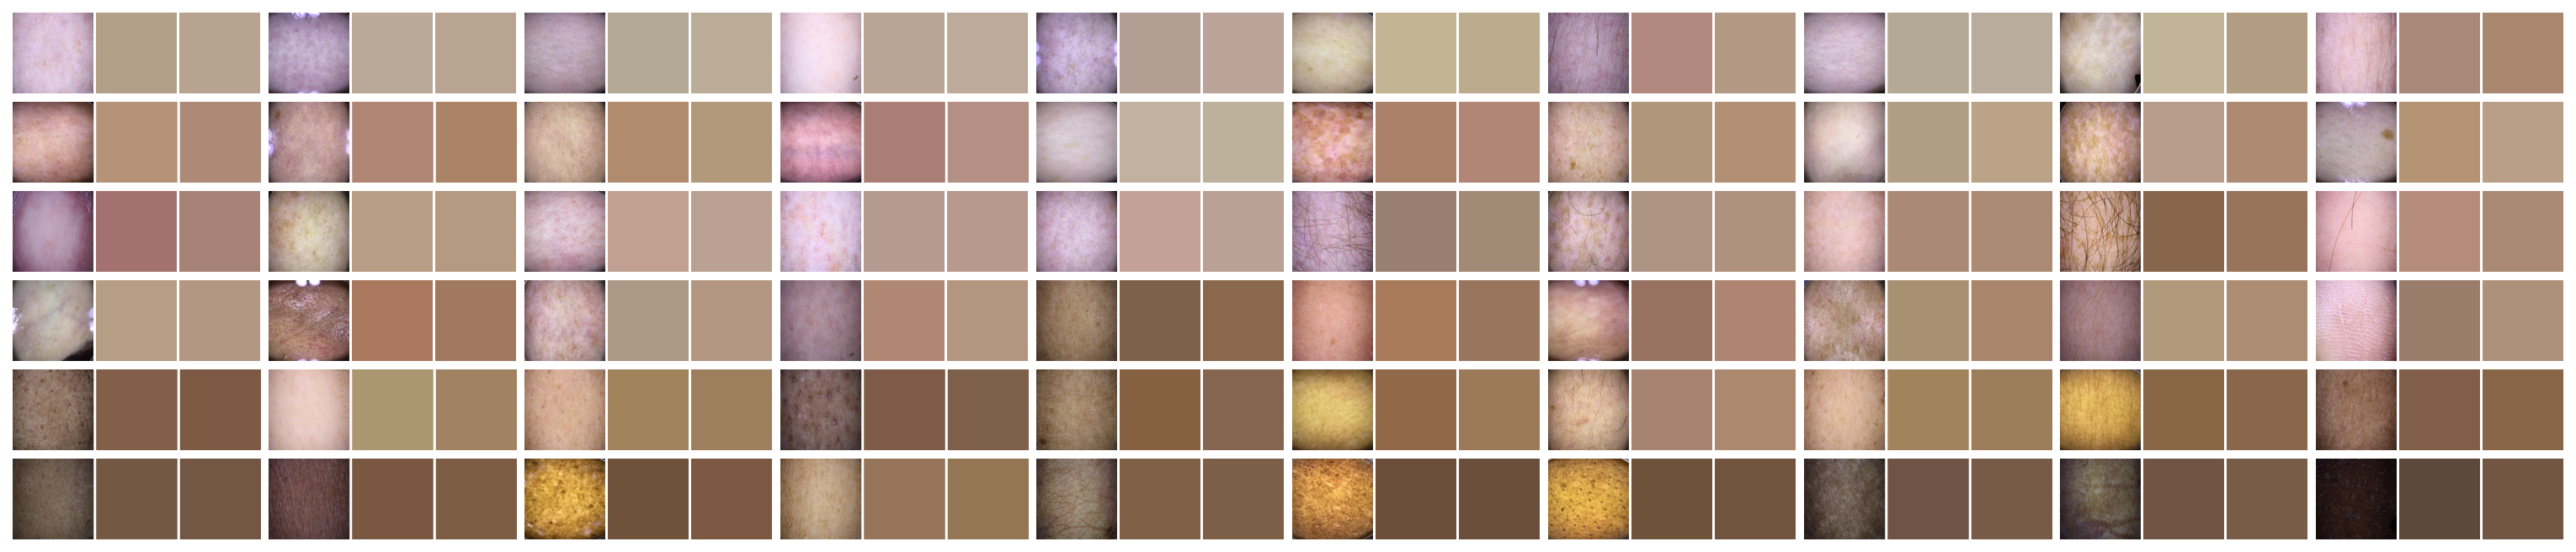

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def lab_to_rgb(L, a, b):
    L = np.asarray(L, dtype=float)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    fy = (L + 16.0) / 116.0
    fx = fy + (a / 500.0)
    fz = fy - (b / 200.0)

    delta = 6.0 / 29.0
    delta3 = delta ** 3

    def finv(t):
        t3 = t ** 3
        return np.where(t3 > delta3, t3, (t - 4.0 / 29.0) * 3.0 * (delta ** 2))

    Xn, Yn, Zn = 95.047, 100.0, 108.883
    X = (Xn * finv(fx)) / 100.0
    Y = (Yn * finv(fy)) / 100.0
    Z = (Zn * finv(fz)) / 100.0

    M = np.array([
        [ 3.2406, -1.5372, -0.4986],
        [-0.9689,  1.8758,  0.0415],
        [ 0.0557, -0.2040,  1.0570],
    ], dtype=float)

    rgb_lin = np.stack([X, Y, Z], axis=-1) @ M.T

    def gamma(u):
        return np.where(u <= 0.0031308, 12.92 * u, 1.055 * np.power(np.maximum(u, 0.0), 1.0 / 2.4) - 0.055)

    rgb = gamma(rgb_lin)
    return np.clip(rgb, 0.0, 1.0)

def make_triplet_cell(img_path, gt_rgb, pred_rgb, *, size=96, sep=3, bg=255):
    try:
        im = Image.open(img_path).convert("RGB")
        im = im.resize((size, size), Image.Resampling.LANCZOS)
        im_arr = np.asarray(im, dtype=np.uint8)
    except Exception:
        im_arr = np.full((size, size, 3), bg, dtype=np.uint8)

    gt = (np.clip(np.asarray(gt_rgb, dtype=float), 0.0, 1.0) * 255.0).round().astype(np.uint8)
    pr = (np.clip(np.asarray(pred_rgb, dtype=float), 0.0, 1.0) * 255.0).round().astype(np.uint8)

    gt_arr = np.zeros((size, size, 3), dtype=np.uint8); gt_arr[:] = gt
    pr_arr = np.zeros((size, size, 3), dtype=np.uint8); pr_arr[:] = pr

    sep_arr = np.full((size, sep, 3), bg, dtype=np.uint8)
    return np.concatenate([im_arr, sep_arr, gt_arr, sep_arr, pr_arr], axis=1)

def show_fp_grid_triplets(
    df: pd.DataFrame,
    *,
    n_cols: int = 10,
    fp_order=("I", "II", "III", "IV", "V", "VI"),
    img_path_col: str = "file",
    fp_col: str = "fitzpatrick_skin_type",
    L_gt_col: str = "L_gt",
    a_gt_col: str = "a_gt",
    b_gt_col: str = "b_gt",
    L_pred_col: str = "L_pred",
    a_pred_col: str = "a_pred",
    b_pred_col: str = "b_pred",
    seed: int = 42,
    cell_size: int = 96,
    swatch_sep_px: int = 3,
    gap_px: int = 10,
    dpi: int = 150,
    left_margin_in: float = 0.55,
    right_margin_in: float = 0.10,
    top_margin_in: float = 0.20,
    bottom_margin_in: float = 0.20,
    label_fontsize: int = 12,
):
    df = df.copy()
    df = df.dropna(subset=[fp_col, img_path_col, L_gt_col, a_gt_col, b_gt_col, L_pred_col, a_pred_col, b_pred_col])

    n_rows = len(fp_order)
    rng = np.random.default_rng(seed)

    cell_w_px = cell_size * 3 + swatch_sep_px * 2
    cell_h_px = cell_size

    cell_w_in = cell_w_px / dpi
    cell_h_in = cell_h_px / dpi
    gap_in = gap_px / dpi

    fig_w = left_margin_in + right_margin_in + n_cols * cell_w_in + (n_cols - 1) * gap_in
    fig_h = top_margin_in + bottom_margin_in + n_rows * cell_h_in + (n_rows - 1) * gap_in

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)

    wspace = gap_in / cell_w_in
    hspace = gap_in / cell_h_in

    gs = fig.add_gridspec(
        n_rows, n_cols,
        left=left_margin_in / fig_w,
        right=1.0 - right_margin_in / fig_w,
        bottom=bottom_margin_in / fig_h,
        top=1.0 - top_margin_in / fig_h,
        wspace=wspace,
        hspace=hspace,
    )

    axes = np.empty((n_rows, n_cols), dtype=object)

    blank = np.full((cell_h_px, cell_w_px, 3), 255, dtype=np.uint8)

    for i, fp in enumerate(fp_order):
        sub = df[df[fp_col].astype(str) == str(fp)].copy()
        if len(sub) > 0:
            idx = rng.choice(sub.index.to_numpy(), size=min(n_cols, len(sub)), replace=False)
            sub = sub.loc[idx].reset_index(drop=True)
        else:
            sub = sub.iloc[0:0].copy()

        for j in range(n_cols):
            ax = fig.add_subplot(gs[i, j])
            axes[i, j] = ax
            ax.set_axis_off()

            if j < len(sub):
                r = sub.iloc[j]
                gt_rgb = lab_to_rgb(r[L_gt_col], r[a_gt_col], r[b_gt_col])
                pr_rgb = lab_to_rgb(r[L_pred_col], r[a_pred_col], r[b_pred_col])
                cell = make_triplet_cell(r[img_path_col], gt_rgb, pr_rgb, size=cell_size, sep=swatch_sep_px)
                ax.imshow(cell)
            else:
                ax.imshow(blank)
    return fig, axes

fig, axes = show_fp_grid_triplets(lab_test_results, n_cols=10, cell_size=96, gap_px=10, dpi=150, seed=42)
plt.show()

fig.savefig("plots/ita_examples.pdf", dpi=150, bbox_inches="tight")

In [18]:
result = patient_bootstrap_mean_ci(lab_test_results, value_col="delta_e", patient_col="patient_id",
                                   n_resamples=5000, method="BCa", random_state=42)
result

{'mean': 4.831965966158845,
 'ci_low': 4.556019744248202,
 'ci_high': 5.323302141792463,
 'n_patients': 46,
 'n_rows': 1385,
 'method': 'BCa',
 'n_resamples': 5000,
 'confidence_level': 0.95}

In [19]:
import pingouin as pg
pg.options['round'] = 3

'''
    Whether and how rounding is applied is governed by options specified in
    `pingouin.options`. The default rounding (number of decimals) is
    determined by `pingouin.options['round']`. You can specify rounding for a
    given column name by the option `'round.column.<colname>'`, e.g.
    `'round.column.CI95%'`. Analogously, `'round.row.<rowname>'` also works
    (where `rowname`) refers to the pandas index), as well as
    `'round.cell.[<rolname>]x[<colname]'`. A cell-based option is used,
    if available; if not, a column-based option is used, if
    available; if not, a row-based option is used, if available; if not,
    the default is used. (Default `pingouin.options['round'] = None`,
    i.e. no rounding is applied.)
'''

def icc(Y):
    n, k = Y.shape
    if n < 2 or k < 2:
        return np.nan, np.nan
    df = pd.DataFrame({
        'subject': np.repeat(np.arange(n), k),
        'rater': np.tile([f'r{i}' for i in range(k)], n),
        'score': Y.reshape(-1),
    })
    pg.options['round'] = 4
    pg.options['round.column.CI95%'] = 4
    icc_tbl = pg.intraclass_corr(data=df, targets='subject', raters='rater', ratings='score')
    return icc_tbl

In [20]:
Y = lab_test_results[['ita_gt', 'ita_pred']].to_numpy()
icc_df = icc(Y)
icc_df

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.9411,32.9419,1384,1385,0.0,"[0.9347, 0.9468]"
1,ICC2,Single random raters,0.9411,32.9992,1384,1384,0.0,"[0.9347, 0.9468]"
2,ICC3,Single fixed raters,0.9412,32.9992,1384,1384,0.0,"[0.9348, 0.9469]"
3,ICC1k,Average raters absolute,0.9696,32.9419,1384,1385,0.0,"[0.9663, 0.9727]"
4,ICC2k,Average random raters,0.9696,32.9992,1384,1384,0.0,"[0.9663, 0.9727]"
5,ICC3k,Average fixed raters,0.9697,32.9992,1384,1384,0.0,"[0.9663, 0.9727]"


In [21]:
import numpy as np
import pandas as pd

SITE_MAP_S7_TO_DF = {
    "upper back": "posterior torso",
    "lower back": "posterior torso",
    "abdomen": "anterior torso",
    "upper chest": "anterior torso",
    "lateral torso": "lateral torso",
    "head/neck": "head/neck",
    "lower leg": "lower extremity",
    "upper leg": "lower extremity",
    "upper arm": "upper extremity",
    "dorsal forearm": "upper extremity",
    "ventral forearm": "upper extremity",
    "palms/soles": "palms/soles",
}

def _icc3_value_ci_complete_rows(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    keep = np.isfinite(x).all(axis=1)
    x = x[keep]
    n_complete = int(x.shape[0])
    if n_complete < 2:
        return np.nan, (np.nan, np.nan), n_complete

    out = icc(x)  # your wrapper, expects (n_subjects, n_raters)
    icc3 = out.loc[out["Type"] == "ICC3"].iloc[0]
    v = float(icc3["ICC"])
    lo, hi = icc3["CI95%"]
    return v, (float(lo), float(hi)), n_complete

s7 = pd.read_csv("data/mskcc/s7.csv")

# Standardize rater column names
if "ita_1" in s7.columns and "ita1" not in s7.columns:
    s7 = s7.rename(columns={"ita_1": "ita1", "ita_2": "ita2", "ita_3": "ita3"})

# Map to your site taxonomy
s7["anatom_site_general"] = s7["anatomic_site"].map(SITE_MAP_S7_TO_DF)

all_sites = sorted(lab_test_results["anatom_site_general"].dropna().unique().tolist())

for site in all_sites:
    sub_ours = lab_test_results[lab_test_results["anatom_site_general"] == site].copy()
    ours_x = sub_ours[["ita_gt", "ita_pred"]].to_numpy()
    ours_icc, ours_ci, ours_n_complete = _icc3_value_ci_complete_rows(ours_x)
    ours_n_raw = int(len(sub_ours))

    sub_h = s7[s7["anatom_site_general"] == site].copy()
    human_n_raw = int(len(sub_h))

    if human_n_raw > 0 and all(c in sub_h.columns for c in ["ita1", "ita2", "ita3"]):
        human_x = sub_h[["ita1", "ita2", "ita3"]].to_numpy()
        human_icc, human_ci, human_n_complete = _icc3_value_ci_complete_rows(human_x)
        human_str = f"{human_icc:.4f} (95% CI: {human_ci[0]:.4f} – {human_ci[1]:.4f})"
    else:
        human_n_complete = 0
        human_str = "—"

    ours_str = "—" if not np.isfinite(ours_icc) else f"{ours_icc:.4f} (95% CI: {ours_ci[0]:.4f} – {ours_ci[1]:.4f})"

    print(
        f"Site: {site} | "
        f"Ours n={ours_n_raw} (complete={ours_n_complete}) ICC3={ours_str} | "
        f"Human (ita1-3) n={human_n_raw} (complete={human_n_complete}) ICC3={human_str}"
    )

Site: anterior torso | Ours n=268 (complete=268) ICC3=0.9496 (95% CI: 0.9363 – 0.9601) | Human (ita1-3) n=355 (complete=352) ICC3=0.9904 (95% CI: 0.9886 – 0.9920)
Site: head/neck | Ours n=128 (complete=128) ICC3=0.9593 (95% CI: 0.9427 – 0.9711) | Human (ita1-3) n=171 (complete=171) ICC3=0.9875 (95% CI: 0.9839 – 0.9904)
Site: lower extremity | Ours n=373 (complete=373) ICC3=0.9017 (95% CI: 0.8808 – 0.9190) | Human (ita1-3) n=339 (complete=339) ICC3=0.9890 (95% CI: 0.9869 – 0.9909)
Site: posterior torso | Ours n=248 (complete=248) ICC3=0.9677 (95% CI: 0.9587 – 0.9747) | Human (ita1-3) n=329 (complete=329) ICC3=0.9891 (95% CI: 0.9869 – 0.9910)
Site: upper extremity | Ours n=368 (complete=368) ICC3=0.9500 (95% CI: 0.9389 – 0.9591) | Human (ita1-3) n=489 (complete=489) ICC3=0.9857 (95% CI: 0.9834 – 0.9877)


In [22]:
import numpy as np
import pandas as pd


pg.options['round'] = 4

SITE_MAP_S7_TO_DF = {
    "upper back": "posterior torso",
    "lower back": "posterior torso",
    "abdomen": "anterior torso",
    "upper chest": "anterior torso",
    "lateral torso": "lateral torso",
    "head/neck": "head/neck",
    "lower leg": "lower extremity",
    "upper leg": "lower extremity",
    "upper arm": "upper extremity",
    "dorsal forearm": "upper extremity",
    "ventral forearm": "upper extremity",
    "palms/soles": "palms/soles",
}

def _esc(s: str) -> str:
    return (
        s.replace("&", r"\&")
         .replace("%", r"\%")
         .replace("_", r"\_")
         .replace("#", r"\#")
    )

def _icc3_value_ci_complete_rows(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    keep = np.isfinite(x).all(axis=1)
    x = x[keep]
    n_complete = int(x.shape[0])
    if n_complete < 2:
        return np.nan, (np.nan, np.nan), n_complete
    out = icc(x)  # your wrapper; returns pg.intraclass_corr table
    icc3 = out.loc[out["Type"] == "ICC3"].iloc[0]
    v = float(icc3["ICC"])
    lo, hi = icc3["CI95%"]
    return v, (float(lo), float(hi)), n_complete

def _fmt_icc_percent(v, lo, hi, *, val_decimals=2):
    if not np.isfinite(v) or not np.isfinite(lo) or not np.isfinite(hi):
        return "—"
    v_pct = v * 100.0
    lo_pct = lo * 100.0
    hi_pct = hi * 100.0
    return f"{v_pct:.{val_decimals}f} ({lo_pct:.2f}, {hi_pct:.2f})"

def icc_by_site_table_to_latex_percent(
    lab_test_results: pd.DataFrame,
    *,
    s7_csv_path: str = "data/mskcc/s7.csv",
    site_col: str = "anatom_site_general",
    ours_cols=("ita_gt", "ita_pred"),
    colorimeter_cols=("ita1", "ita2", "ita3"),
    val_decimals: int = 2,
    caption: str = "ICC3 by anatomical site (\\% and 95\\% CI).",
    label: str = "tab:icc_by_site",
    image_based_csv_path: str = "inference_results/infer=mskcc_model=image_based.csv",
):
    s7 = pd.read_csv(s7_csv_path)

    if "ita_1" in s7.columns and "ita1" not in s7.columns:
        s7 = s7.rename(columns={"ita_1": "ita1", "ita_2": "ita2", "ita_3": "ita3"})

    if "anatomic_site" in s7.columns:
        s7[site_col] = s7["anatomic_site"].map(SITE_MAP_S7_TO_DF)
    else:
        s7[site_col] = np.nan

    sites = sorted(lab_test_results[site_col].dropna().unique().tolist())

    rows = []
    for site in sites:
        sub = lab_test_results[lab_test_results[site_col] == site].copy()
        v, (lo, hi), n_used = _icc3_value_ci_complete_rows(sub[list(ours_cols)].to_numpy())
        cell = _fmt_icc_percent(v, lo, hi, val_decimals=val_decimals)
        rows.append({"Site": str(site), "n": int(n_used), "ICC3 [%] (95\\% CI)": cell})

    site_df = pd.DataFrame(rows)

    # --- Overall (Ours vs GT) ---
    ours_v, (ours_lo, ours_hi), ours_n = _icc3_value_ci_complete_rows(
        lab_test_results[list(ours_cols)].to_numpy()
    )
    ours_cell = _fmt_icc_percent(ours_v, ours_lo, ours_hi, val_decimals=val_decimals)

    # --- Overall (Colorimeter repeatability) ---
    col_v, (col_lo, col_hi), col_n = _icc3_value_ci_complete_rows(
        s7[list(colorimeter_cols)].to_numpy()
    )
    col_cell = _fmt_icc_percent(col_v, col_lo, col_hi, val_decimals=val_decimals)

    # --- Overall (Bevan + KMeans vs GT) ---
    img_based = pd.read_csv(image_based_csv_path)
    img_based["isic_id"] = img_based["file"].apply(lambda p: str(p).split("/")[-1].split(".")[0])

    base = lab_test_results[["isic_id", "ita_gt"]].dropna().copy()
    img_based = img_based.merge(base, on="isic_id", how="inner")

    bevan_v, (bevan_lo, bevan_hi), bevan_n = _icc3_value_ci_complete_rows(
        img_based[["ita_gt", "ita_bevan"]].to_numpy()
    )
    bevan_cell = _fmt_icc_percent(bevan_v, bevan_lo, bevan_hi, val_decimals=val_decimals)

    kmeans_v, (kmeans_lo, kmeans_hi), kmeans_n = _icc3_value_ci_complete_rows(
        img_based[["ita_gt", "ita_kmeans"]].to_numpy()
    )
    kmeans_cell = _fmt_icc_percent(kmeans_v, kmeans_lo, kmeans_hi, val_decimals=val_decimals)

    # --- Build LaTeX ---
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{threeparttable}")
    lines.append(r"\begin{tabularx}{\textwidth}{@{}X r >{\raggedright\arraybackslash}l@{}}")
    lines.append(r"\toprule")
    lines.append(r"Site & $n$ & ICC3 [\%] (95\% CI) \\")
    lines.append(r"\midrule")

    for _, r in site_df.iterrows():
        s = _esc(str(r["Site"]))
        n = int(r["n"])
        cell = str(r["ICC3 [%] (95\\% CI)"])
        lines.append(rf"{s} & {n} & {cell} \\")

    lines.append(r"\midrule")
    lines.append(rf"\textbf{{Ours}} & {int(ours_n)} & {ours_cell} \\")
    lines.append(rf"\textbf{{Bevan}} & {int(bevan_n)} & {bevan_cell} \\")
    lines.append(rf"\textbf{{KMeans}} & {int(kmeans_n)} & {kmeans_cell} \\")
    lines.append(rf"\textbf{{Colorimeter\tnote{{a}}}} & {int(col_n)} & {col_cell} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabularx}")
    lines.append(r"\begin{tablenotes}[flushleft]")
    lines.append(r"\footnotesize")
    lines.append(r"\item[a] ICC3 across three repeated ITA measurements (ita1--ita3) from the colorimeter dataset (MSKCC s7).")
    lines.append(r"\end{tablenotes}")
    lines.append(r"\end{threeparttable}")
    lines.append(r"\end{table}")

    latex_str = "\n".join(lines)
    return site_df, latex_str


# --- Usage ---
site_icc_df, site_icc_latex = icc_by_site_table_to_latex_percent(
    lab_test_results,
    s7_csv_path="data/mskcc/s7.csv",
    site_col="anatom_site_general",
    ours_cols=("ita_gt", "ita_pred"),
    colorimeter_cols=("ita1", "ita2", "ita3"),
    val_decimals=2,
    caption="ICC3 by anatomical site (\\% and 95\\% CI).",
    label="tab:icc_by_site",
    image_based_csv_path="inference_results/infer=mskcc_model=image_based.csv",
)

print(site_icc_df)
print("\n" + site_icc_latex)

              Site    n    ICC3 [%] (95\% CI)
0   anterior torso  268  94.96 (93.63, 96.01)
1        head/neck  128  95.93 (94.27, 97.11)
2  lower extremity  373  90.17 (88.08, 91.90)
3  posterior torso  248  96.77 (95.87, 97.47)
4  upper extremity  368  95.00 (93.89, 95.91)

\begin{table}[t]
\centering
\small
\caption{ICC3 by anatomical site (\% and 95\% CI).}
\label{tab:icc_by_site}
\begin{threeparttable}
\begin{tabularx}{\textwidth}{@{}X r >{\raggedright\arraybackslash}l@{}}
\toprule
Site & $n$ & ICC3 [\%] (95\% CI) \\
\midrule
anterior torso & 268 & 94.96 (93.63, 96.01) \\
head/neck & 128 & 95.93 (94.27, 97.11) \\
lower extremity & 373 & 90.17 (88.08, 91.90) \\
posterior torso & 248 & 96.77 (95.87, 97.47) \\
upper extremity & 368 & 95.00 (93.89, 95.91) \\
\midrule
\textbf{Ours} & 1385 & 94.12 (93.48, 94.69) \\
\textbf{Bevan} & 1385 & 61.97 (58.62, 65.11) \\
\textbf{KMeans} & 1385 & 42.96 (38.57, 47.16) \\
\textbf{Colorimeter\tnote{a}} & 1838 & 98.38 (98.24, 98.50) \\
\bottomrule
\e

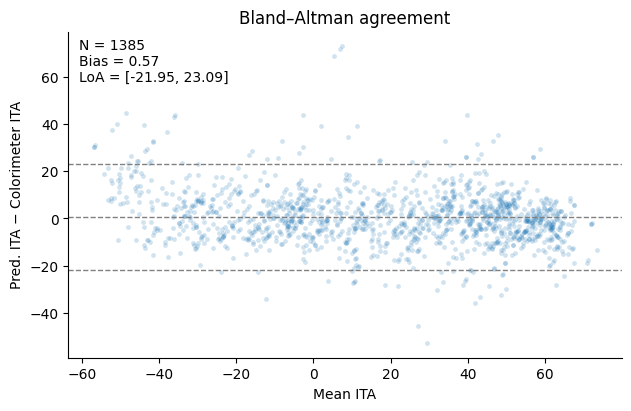

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def bland_altman_plot(data1, data2, ax=None, *args, **kwargs):
    if ax is None:
        ax = plt.gca()

    data1 = np.asarray(data1, dtype=float)
    data2 = np.asarray(data2, dtype=float)

    mean = np.mean([data1, data2], axis=0)
    diff = data2 - data1  # Pred − GT

    md = np.mean(diff)
    sd = np.std(diff, axis=0)

    ax.scatter(mean, diff, *args, **kwargs)
    ax.axhline(md, color="gray", linestyle="--", linewidth=1)
    ax.axhline(md + 1.96 * sd, color="gray", linestyle="--", linewidth=1)
    ax.axhline(md - 1.96 * sd, color="gray", linestyle="--", linewidth=1)

    ax.set_xlabel("Mean ITA")
    ax.set_ylabel("Pred. ITA − Colorimeter ITA")
    ax.set_title("Bland–Altman agreement")

    return ax, md, sd

# --- Data ---
x = lab_test_results["ita_gt"].to_numpy(dtype=float)
y = lab_test_results["ita_pred"].to_numpy(dtype=float)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]
n = len(x)

fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.0), constrained_layout=True)

ax, md, sd = bland_altman_plot(
    x, y,
    ax=ax,
    s=12,
    alpha=0.2,
    linewidths=0,
    rasterized=True,
)

ax.text(
    0.02, 0.98,
    f"N = {n}\nBias = {md:.2f}\nLoA = [{md - 1.96*sd:.2f}, {md + 1.96*sd:.2f}]",
    transform=ax.transAxes,
    va="top",
    ha="left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# Save for paper
fig.savefig("plots/ita_bland_altman.pdf", bbox_inches="tight")

In [24]:
import numpy as np
import pandas as pd

def site_kappa_table_to_latex_percent_ours_vs_model(
    test_results: pd.DataFrame,
    *,
    other_csv_path: str = "test_results/finetune_mskcc_blur0_classification.csv",
    other_name: str = "Baseline",
    site_col: str = "anatom_site_general",
    patient_col: str = "isic_id",
    y_true_col: str = "fp",
    y_pred_col_ours: str = "pred",
    y_pred_col_other: str = "pred",
    weights: str = "linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples: int = 2000,
    confidence_level: float = 0.95,
    method: str = "BCa",
    random_state: int = 42,
    min_patients: int = 2,
    caption: str = "Patient-level Cohen's $\\kappa$ by anatomical site (\\% and 95\\% CI): Ours vs Baseline.",
    label: str = "tab:kappa_by_site_ours_vs_baseline",
    site_order=("anterior torso", "head/neck", "lateral torso", "lower extremity", "palms/soles", "posterior torso", "upper extremity"),
):
    def _esc(s: str) -> str:
        return (
            s.replace("&", r"\&")
             .replace("%", r"\%")
             .replace("_", r"\_")
             .replace("#", r"\#")
        )

    def _format_cell(k, lo, hi):
        if pd.isna(k) or pd.isna(lo) or pd.isna(hi):
            return "—"
        return f"{k*100:.2f} ({lo*100:.2f}, {hi*100:.2f})"

    def _compute_site_rows(df_in: pd.DataFrame, *, pred_col: str):
        df = df_in[[site_col, patient_col, y_true_col, pred_col]].copy()
        df = df.dropna(subset=[site_col, patient_col, y_true_col, pred_col])

        sites_found = [str(s) for s in df[site_col].dropna().unique().tolist()]
        sites_ordered = [s for s in site_order if s in sites_found] + [s for s in sorted(sites_found) if s not in site_order]

        rows = []
        for site in sites_ordered:
            sdf = df[df[site_col] == site].copy()
            n_pat = int(sdf[patient_col].nunique())
            n_rows = int(len(sdf))

            if n_pat < min_patients:
                rows.append({
                    "Site": str(site),
                    "Images (n)": n_rows,
                    "kappa": np.nan,
                    "ci_low": np.nan,
                    "ci_high": np.nan,
                    "Kappa [%] (95\\% CI)": "—",
                })
                continue

            res = patient_bootstrap_kappa_ci(
                sdf,
                patient_col=patient_col,
                y_true_col=y_true_col,
                y_pred_col=pred_col,
                weights=weights,
                labels=labels,
                n_resamples=n_resamples,
                confidence_level=confidence_level,
                method=method,
                random_state=random_state,
            )

            k, lo, hi = float(res["kappa"]), float(res["ci_low"]), float(res["ci_high"])
            rows.append({
                "Site": str(site),
                "Images (n)": n_rows,
                "kappa": k,
                "ci_low": lo,
                "ci_high": hi,
                "Kappa [%] (95\\% CI)": _format_cell(k, lo, hi),
            })

        df_out = pd.DataFrame(rows)

        overall = None
        n_rows_all = int(len(df))
        n_pat_all = int(df[patient_col].nunique())
        if n_pat_all >= min_patients:
            overall = patient_bootstrap_kappa_ci(
                df,
                patient_col=patient_col,
                y_true_col=y_true_col,
                y_pred_col=pred_col,
                weights=weights,
                labels=labels,
                n_resamples=n_resamples,
                confidence_level=confidence_level,
                method=method,
                random_state=random_state,
            )

        return df_out, overall, n_rows_all

    # --- Ours (already has site/patient/gt/pred) ---
    ours_df, ours_overall, ours_n_all = _compute_site_rows(test_results, pred_col=y_pred_col_ours)

    # --- Other model: read CSV, majority-vote across folds per image, then merge site info from test_results ---
    other = pd.read_csv(other_csv_path)
    other["isic_id"] = other["file"].apply(lambda p: str(p).split("/")[-1].split(".")[0])

    other_agg = (
        other.groupby("isic_id", as_index=False)
             .agg(
                 fp=(y_true_col, "first"),
                 pred=(y_pred_col_other, lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
             )
    )

    site_info = test_results[[patient_col, site_col]].dropna().drop_duplicates(subset=[patient_col])
    other_agg = other_agg.merge(site_info, on="isic_id", how="left")

    raters_df, raters_overall, raters_n_all = _compute_site_rows(other_agg, pred_col="pred")

    # --- Merge rows for LaTeX ---
    sites_union = (
        [s for s in site_order if (s in set(ours_df["Site"]) or s in set(raters_df["Site"]))] +
        [s for s in sorted(set(ours_df["Site"]).union(set(raters_df["Site"]))) if s not in site_order]
    )

    ours_df_idx = ours_df.set_index("Site")
    other_df_idx = raters_df.set_index("Site")

    merged_rows = []
    for site in sites_union:
        o = ours_df_idx.loc[site] if site in ours_df_idx.index else None
        b = other_df_idx.loc[site] if site in other_df_idx.index else None

        merged_rows.append({
            "Site": site,
            "Ours Images (n)": int(o["Images (n)"]) if o is not None else 0,
            "Ours Kappa [%] (95\\% CI)": str(o["Kappa [%] (95\\% CI)"]) if o is not None else "—",
            "Other Images (n)": int(b["Images (n)"]) if b is not None else 0,
            "Other Kappa [%] (95\\% CI)": str(b["Kappa [%] (95\\% CI)"]) if b is not None else "—",
        })

    out_df = pd.DataFrame(merged_rows)

    # --- Build LaTeX ---
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{5pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.15}")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{@{}l r l r l@{}}")
    lines.append(r"\toprule")
    lines.append(rf" & \multicolumn{{2}}{{c}}{{\textbf{{Ours}}}} & \multicolumn{{2}}{{c}}{{\textbf{{{_esc(other_name)}}}}} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r"Site & Images ($n$) & $\kappa$ [\%] (95\% CI) & Images ($n$) & $\kappa$ [\%] (95\% CI) \\")
    lines.append(r"\midrule")

    for _, rr in out_df.iterrows():
        site = _esc(str(rr["Site"]))
        o_im = int(rr["Ours Images (n)"])
        o_k = rr["Ours Kappa [%] (95\\% CI)"]
        b_im = int(rr["Other Images (n)"])
        b_k = rr["Other Kappa [%] (95\\% CI)"]
        lines.append(rf"{site} & {o_im} & {o_k} & {b_im} & {b_k} \\")

    lines.append(r"\midrule")

    if ours_overall is None:
        o_over = "—"
    else:
        o_over = _format_cell(float(ours_overall["kappa"]), float(ours_overall["ci_low"]), float(ours_overall["ci_high"]))

    if raters_overall is None:
        b_over = "—"
    else:
        b_over = _format_cell(float(raters_overall["kappa"]), float(raters_overall["ci_low"]), float(raters_overall["ci_high"]))

    lines.append(rf"\textbf{{Overall}} & {ours_n_all} & {o_over} & {raters_n_all} & {b_over} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    latex_str = "\n".join(lines)
    return out_df, latex_str


# --- Usage ---
site_kappa_df_ours_vs_baseline, site_kappa_latex_ours_vs_baseline = site_kappa_table_to_latex_percent_ours_vs_model(
    test_results,
    other_csv_path="test_results/finetune_mskcc_blur0_classification.csv",
    other_name="Classification",
    site_col="anatom_site_general",
    patient_col="isic_id",
    y_true_col="fp",
    y_pred_col_ours="pred",
    y_pred_col_other="pred",
    weights="linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples=2000,
    confidence_level=0.95,
    method="BCa",
    random_state=42,
)

print(site_kappa_df_ours_vs_baseline)
print("\n" + site_kappa_latex_ours_vs_baseline)


              Site  Ours Images (n) Ours Kappa [%] (95\% CI)  \
0   anterior torso              683     51.57 (47.84, 55.10)   
1        head/neck              301     56.04 (51.65, 60.44)   
2    lateral torso               30     42.15 (21.57, 59.36)   
3  lower extremity              778     49.18 (45.94, 52.28)   
4      palms/soles               26      14.57 (5.50, 28.06)   
5  posterior torso              928     54.96 (52.06, 57.75)   
6  upper extremity              932     54.30 (51.14, 57.16)   

   Other Images (n) Other Kappa [%] (95\% CI)  
0               683      49.44 (44.68, 54.56)  
1               301      43.20 (35.34, 50.94)  
2                30       31.82 (5.48, 65.57)  
3               778      40.30 (35.14, 45.18)  
4                26       10.62 (3.36, 25.33)  
5               928      45.83 (41.68, 49.84)  
6               932      49.55 (44.98, 53.34)  

\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\cap

In [20]:
site_kappa_df_ours_vs_baseline, site_kappa_latex_ours_vs_baseline = site_kappa_table_to_latex_percent_ours_vs_model(
    test_results,
    other_csv_path="test_results/finetune_mskcc_blur0_wb.csv",
    other_name="White Balancing",
    site_col="anatom_site_general",
    patient_col="isic_id",
    y_true_col="fp",
    y_pred_col_ours="pred",
    y_pred_col_other="pred",
    weights="linear",
    labels=(1, 2, 3, 4, 5, 6),
    n_resamples=2000,
    confidence_level=0.95,
    method="BCa",
    random_state=42,
)

print(site_kappa_df_ours_vs_baseline)
print("\n" + site_kappa_latex_ours_vs_baseline)


              Site  Ours Images (n) Ours Kappa [%] (95\% CI)  \
0   anterior torso              907     52.11 (49.01, 55.09)   
1        head/neck              398     55.16 (51.14, 59.07)   
2    lateral torso               40     42.90 (26.90, 58.07)   
3  lower extremity             1033     49.52 (46.75, 52.32)   
4      palms/soles               35      15.19 (7.26, 27.14)   
5  posterior torso             1231     54.45 (51.87, 57.10)   
6  upper extremity             1235     54.29 (51.64, 56.71)   

   Other Images (n) Other Kappa [%] (95\% CI)  
0               907      50.27 (46.63, 53.66)  
1               398      52.03 (47.04, 57.04)  
2                40      47.06 (34.78, 64.00)  
3              1033      46.17 (42.86, 49.68)  
4                35       12.40 (5.71, 23.98)  
5              1231      53.98 (51.13, 56.68)  
6              1235      52.00 (48.72, 55.03)  

\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\cap

In [24]:
import numpy as np
import pandas as pd

def compare_mae_bias_by_fp_two_csv_to_latex(
    csv_a_path: str,
    csv_b_path: str,
    *,
    method_a_name: str = "A",
    method_b_name: str = "B",
    y_true_col: str = "fp",
    y_pred_col: str = "pred",
    labels=(0, 1, 2, 3, 4, 5),
    n_resamples: int = 2000,
    confidence_level: float = 0.95,
    random_state: int = 42,
    caption: str = "Per-class MAE and bias (mean and 95\\% CI): Method A vs Method B.",
    label: str = "tab:mae_bias_by_fp_two_methods",
):
    def _esc(s: str) -> str:
        return (
            str(s).replace("&", r"\&")
                  .replace("%", r"\%")
                  .replace("_", r"\_")
                  .replace("#", r"\#")
        )

    def _bootstrap_ci(values: np.ndarray, fn):
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]
        n = int(values.size)
        if n < 2:
            return np.nan, np.nan, np.nan
        rng = np.random.default_rng(random_state)
        stats = np.empty(n_resamples, dtype=float)
        for i in range(n_resamples):
            samp = rng.choice(values, size=n, replace=True)
            stats[i] = float(fn(samp))
        alpha = 1.0 - float(confidence_level)
        lo = float(np.quantile(stats, alpha / 2.0))
        hi = float(np.quantile(stats, 1.0 - alpha / 2.0))
        m = float(fn(values))
        return m, lo, hi

    def _fmt(m, lo, hi):
        if not (np.isfinite(m) and np.isfinite(lo) and np.isfinite(hi)):
            return "—"
        return f"{m:.2f} ({lo:.2f}, {hi:.2f})"

    def _per_class(df: pd.DataFrame):
        df = df[[y_true_col, y_pred_col]].dropna().copy()
        df[y_true_col] = df[y_true_col].astype(int)
        df[y_pred_col] = df[y_pred_col].astype(int)
        err = (df[y_pred_col] - df[y_true_col]).to_numpy(dtype=float)
        abs_err = np.abs(err)

        rows = []
        for k in labels:
            mask = (df[y_true_col].to_numpy(dtype=int) == int(k))
            e = err[mask]
            ae = abs_err[mask]
            n = int(mask.sum())
            if n == 0:
                rows.append({"fp": int(k), "n": 0, "mae": "—", "bias": "—"})
                continue
            mae_m, mae_lo, mae_hi = _bootstrap_ci(ae, np.mean)
            bias_m, bias_lo, bias_hi = _bootstrap_ci(e, np.mean)
            rows.append({
                "fp": int(k),
                "n": n,
                "mae": _fmt(mae_m, mae_lo, mae_hi),
                "bias": _fmt(bias_m, bias_lo, bias_hi),
            })

        mae_m, mae_lo, mae_hi = _bootstrap_ci(abs_err, np.mean)
        bias_m, bias_lo, bias_hi = _bootstrap_ci(err, np.mean)
        overall = {
            "n": int(len(df)),
            "mae": _fmt(mae_m, mae_lo, mae_hi),
            "bias": _fmt(bias_m, bias_lo, bias_hi),
        }
        return pd.DataFrame(rows).set_index("fp"), overall

    df_a = pd.read_csv(csv_a_path)
    df_b = pd.read_csv(csv_b_path)

    per_a, overall_a = _per_class(df_a)
    per_b, overall_b = _per_class(df_b)

    out = []
    for k in labels:
        out.append({
            "Fitzpatrick": int(k),
            "A_n": int(per_a.loc[int(k), "n"]),
            "A_MAE": str(per_a.loc[int(k), "mae"]),
            "A_Bias": str(per_a.loc[int(k), "bias"]),
            "B_n": int(per_b.loc[int(k), "n"]),
            "B_MAE": str(per_b.loc[int(k), "mae"]),
            "B_Bias": str(per_b.loc[int(k), "bias"]),
        })
    out_df = pd.DataFrame(out)

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{5pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.15}")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{threeparttable}")
    lines.append(r"\begin{tabularx}{\textwidth}{@{}X r l l r l l@{}}")
    lines.append(r"\toprule")
    lines.append(rf" & \multicolumn{{3}}{{c}}{{\textbf{{{_esc(method_a_name)}}}}} & \multicolumn{{3}}{{c}}{{\textbf{{{_esc(method_b_name)}}}}} \\")
    lines.append(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
    lines.append(r"Fitzpatrick & $n$ & MAE & Bias & $n$ & MAE & Bias \\")
    lines.append(r"\midrule")

    for _, r in out_df.iterrows():
        lines.append(
            rf"{int(r['Fitzpatrick']) + 1} & {int(r['A_n'])} & {r['A_MAE']} & {r['A_Bias']} & "
            rf"{int(r['B_n'])} & {r['B_MAE']} & {r['B_Bias']} \\"
        )

    lines.append(r"\midrule")
    lines.append(
        rf"\textbf{{Overall}} & {int(overall_a['n'])} & {overall_a['mae']} & {overall_a['bias']} & "
        rf"{int(overall_b['n'])} & {overall_b['mae']} & {overall_b['bias']} \\"
    )
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabularx}")
    lines.append(r"\end{threeparttable}")
    lines.append(r"\end{table}")

    latex_str = "\n".join(lines)
    return out_df, latex_str


df_cmp, latex_cmp = compare_mae_bias_by_fp_two_csv_to_latex(
    "test_results/finetune_mskcc_blur0.csv",
    "test_results/finetune_mskcc_blur0_wb.csv",
    method_a_name="Ordinal Regression",
    method_b_name="White Balancing",
    caption="Per-class MAE and bias (mean and 95\\% CI): Ordinal regression vs classification.",
    label="tab:fp_mae_bias_two_methods",
)
print(latex_cmp)


\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\caption{Per-class MAE and bias (mean and 95\% CI): Ordinal regression vs classification.}
\label{tab:fp_mae_bias_two_methods}
\begin{threeparttable}
\begin{tabularx}{\textwidth}{@{}X r l l r l l@{}}
\toprule
 & \multicolumn{3}{c}{\textbf{Ordinal Regression}} & \multicolumn{3}{c}{\textbf{White Balancing}} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Fitzpatrick & $n$ & MAE & Bias & $n$ & MAE & Bias \\
\midrule
1 & 789 & 1.21 (1.17, 1.25) & 1.21 (1.17, 1.25) & 789 & 1.28 (1.23, 1.32) & 1.28 (1.23, 1.32) \\
2 & 950 & 0.53 (0.49, 0.57) & 0.47 (0.43, 0.52) & 950 & 0.61 (0.57, 0.65) & 0.56 (0.52, 0.61) \\
3 & 794 & 0.71 (0.68, 0.75) & -0.57 (-0.62, -0.52) & 794 & 0.72 (0.69, 0.76) & -0.40 (-0.45, -0.34) \\
4 & 783 & 1.04 (1.00, 1.09) & -0.33 (-0.42, -0.25) & 783 & 0.88 (0.83, 0.93) & -0.29 (-0.37, -0.21) \\
5 & 813 & 0.77 (0.70, 0.83) & -0.43 (-0.51, -0.35) & 813 & 0.73 (0.67, 0.79) & -0.52 (-0.59, 